# **Section 6: K-Nearest Neighbors Classification**

In this notebook, I will train and evaluate K-Nearest Neighbors (KNN) models. I will start by training a model with a default number of neighbors (k=5), and will then tune the number of neighbors using a cross-validated grid search.

## **1. Importing the Data**

Let's import the training, validation, and test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load Features**

In [2]:
# Load features and labels
cnv_train = pd.read_csv("Data/cnv_train.csv", index_col=0)
cnv_test = pd.read_csv("Data/cnv_test.csv", index_col=0)
profiles_train = pd.read_csv("Data/SXT_train.csv", index_col=0)
profiles_test = pd.read_csv("Data/SXT_test.csv", index_col=0)

X_train = cnv_train.values
y_train = profiles_train.values

X_test = cnv_test.values
y_test = profiles_test.values

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Categories: {np.unique(y_train)}")

Training set shape: (173, 7197)
Test set shape: (48, 7197)
Categories: [0 1]


## **2. K-Nearest Neighbors with Default Hyperparameters**

Let's start with a baseline KNN model using default parameters (k=5).

In [3]:
# Create KNN pipeline with standardization
knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# Train the model
knn.fit(X_train, y_train)

print("KNN model trained with k=5")

KNN model trained with k=5


### **2.1 Evaluate Baseline Model**

In [4]:
# Evaluate on training, validation, and test sets
accuracy_train = knn.score(X_train, y_train)
accuracy_test = knn.score(X_test, y_test)

print(f"Accuracy training set (k=5): {accuracy_train:.4f}")
print(f"Accuracy test set (k=5): {accuracy_test:.4f}")

Accuracy training set (k=5): 0.9480
Accuracy test set (k=5): 0.9583


### **2.2 Classification Report and Confusion Matrix**

In [5]:
# Get predictions
y_test_pred = knn.predict(X_test)

# Classification report
print("Classification Report (k=5):")
print(classification_report(y_test, y_test_pred))

Classification Report (k=5):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        29
           1       0.90      1.00      0.95        19

    accuracy                           0.96        48
   macro avg       0.95      0.97      0.96        48
weighted avg       0.96      0.96      0.96        48



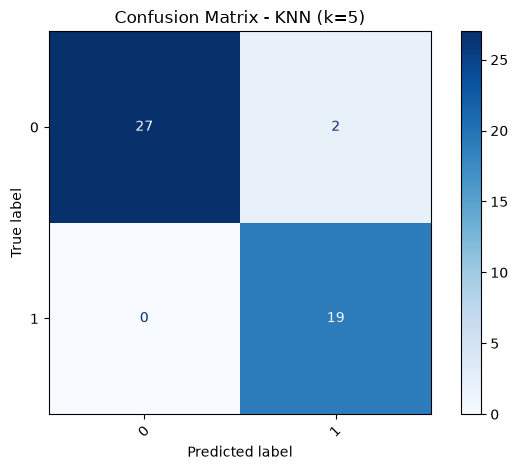

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - KNN (k=5)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing k**

Now let's use cross-validated grid search to find the optimal number of neighbors.

### **3.1 Grid Search for Optimal k**

In [7]:
# Create KNN pipeline for grid search
knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

# Define parameter grid
param_grid = {'kneighborsclassifier__n_neighbors': [1, 5, 10, 15, 20, 25, 30, 35, 40]}

# Create grid search
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'kneighborsclassifier__n_neighbors': 1}
Best cross-validation score: 0.8958


### **3.3 Analyze Grid Search Results**

In [8]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display key results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_kneighborsclassifier__n_neighbors'
]].sort_values('mean_test_score', ascending=False)

print("\nGrid Search Results (sorted by validation score):")
print(results_display)


Grid Search Results (sorted by validation score):
   mean_test_score  std_test_score  mean_train_score  std_train_score  \
0         0.895798        0.089811          1.000000         0.000000   
1         0.878487        0.099999          0.950860         0.016793   
2         0.861176        0.098496          0.923366         0.030694   
7         0.855462        0.118840          0.893056         0.025284   
6         0.855462        0.107288          0.919039         0.028104   
8         0.849748        0.112258          0.859827         0.014887   
3         0.849748        0.098301          0.923366         0.027057   
5         0.844034        0.100178          0.919070         0.026495   
4         0.838319        0.103293          0.919049         0.028831   

   param_kneighborsclassifier__n_neighbors  
0                                        1  
1                                        5  
2                                       10  
7                                     

### **3.4 Visualize Training/Validation Accuracy Curves**

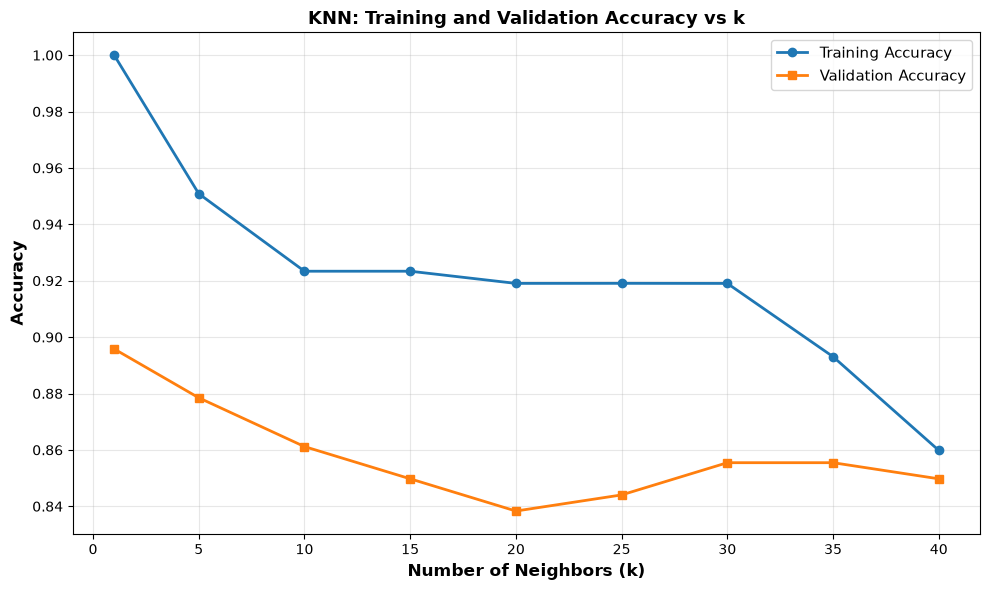

In [9]:
# Sort results by k value for plotting
cv_results_sorted = cv_results.sort_values('param_kneighborsclassifier__n_neighbors')

# Plot accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(
    cv_results_sorted['param_kneighborsclassifier__n_neighbors'],
    cv_results_sorted['mean_train_score'],
    label='Training Accuracy',
    marker='o',
    linewidth=2
)
plt.plot(
    cv_results_sorted['param_kneighborsclassifier__n_neighbors'],
    cv_results_sorted['mean_test_score'],
    label='Validation Accuracy',
    marker='s',
    linewidth=2
)

plt.xlabel('Number of Neighbors (k)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN: Training and Validation Accuracy vs k', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/05_knn_training_curve", dpi=300)
plt.show()

## **4. Evaluate Best Model**

In [10]:
# Evaluate best model on test set
best_knn = grid_search.best_estimator_
accuracy_test_best = best_knn.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best k value: {grid_search.best_params_['kneighborsclassifier__n_neighbors']}")


Best Model Test Accuracy: 0.9583
Best k value: 1


### **4.1 Classification Report**

In [11]:
# Get predictions
y_test_pred_best = best_knn.predict(X_test)

# Classification report
print("\nClassification Report (Best KNN):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best KNN):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.95      0.95      0.95        19

    accuracy                           0.96        48
   macro avg       0.96      0.96      0.96        48
weighted avg       0.96      0.96      0.96        48



### **4.2 Confusion Matrix**

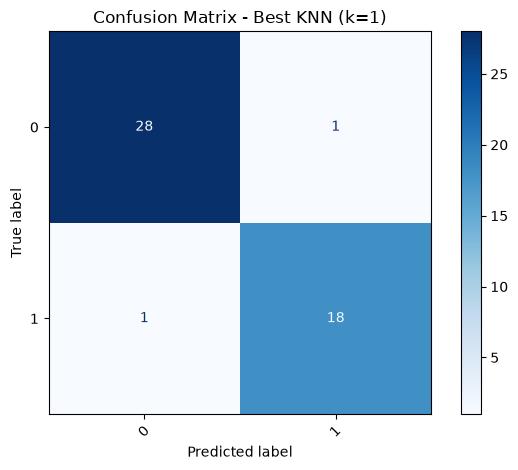

In [12]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_knn.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_knn.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best KNN (k={grid_search.best_params_['kneighborsclassifier__n_neighbors']})")
plt.tight_layout()
plt.savefig("Figures/05_knn_cm", dpi=300)
plt.show()

### **4.3 ROC Curve and AUC Score**

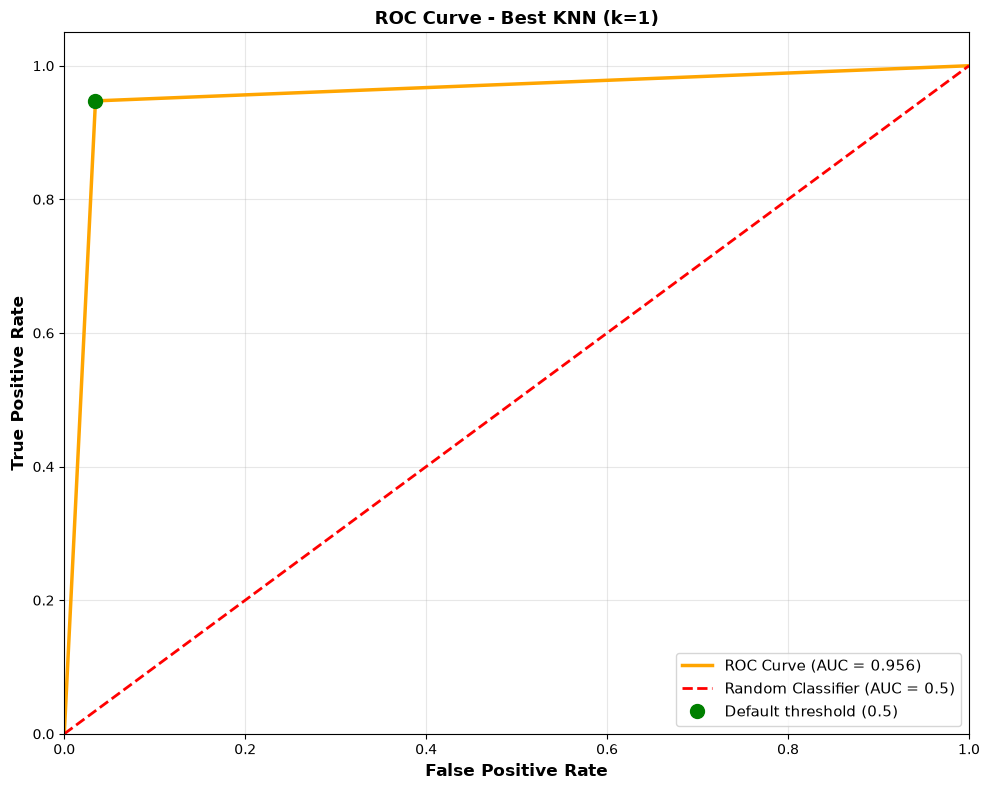


AUC Score: 0.9564
At default threshold (0.5):
  True Positive Rate (TPR): 0.947 (catch 94.7% of resistant)
  False Positive Rate (FPR): 0.034 (3.4% of susceptible misclassified)


In [13]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_knn.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='orange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best KNN (k={grid_search.best_params_["kneighborsclassifier__n_neighbors"]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/05_knn_ROC", dpi=300)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Model Results**

In [14]:
import csv
import os

# Store results
results = {
    'model': 'K-Nearest Neighbors',
    'hyperparameters': f"k={grid_search.best_params_['kneighborsclassifier__n_neighbors']}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = "Results/model_results.csv"

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: K-Nearest Neighbors
  Hyperparameters: k=1
  Test Accuracy: 0.9583
  CV Score: 0.8958
